# Binary Classification with CNNs

import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense 


In [5]:
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense 
# import label encoder
from sklearn.preprocessing import LabelEncoder


In [6]:
# load the dataset
tips = sns.load_dataset("tips")

In [8]:
# prepare the data
# encoding the categorical data
le = LabelEncoder()
tips['sex'] = le.fit_transform(tips['sex'])
tips['smoker'] = le.fit_transform(tips['smoker'])
tips['day'] = le.fit_transform(tips['day'])
tips['time'] = le.fit_transform(tips['time'])

# create a binary target variable for binary classification
median_bill = tips['total_bill'].median()
tips['high_bill'] = (tips['total_bill'] > median_bill).astype(int)

# split the data into features and target
X = tips.drop(['total_bill', 'high_bill'], axis=1)
y = tips['high_bill']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the feature data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Build the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(8, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  
])

# compile the model
model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

# train the model
model.fit(X_train, y_train, epochs=5, batch_size= 32)


# evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print('Test Accuracy: %.2f' % (accuracy * 100))



Epoch 1/5


c:\Users\mk\miniconda3\envs\tensorflow_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5282 - loss: 0.6764
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5641 - loss: 0.6655 
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6000 - loss: 0.6560 
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6462 - loss: 0.6470 
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6872 - loss: 0.6390 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5714 - loss: 0.6378 
Test Accuracy: 57.14


# Multiclass classification with CNNs


In [13]:
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from keras.models import Sequential
from keras.layers import Dense

#load the dataset
tips = sns.load_dataset("tips")

# process the data
# encoding the categorical data
le = LabelEncoder()
tips['sex'] = le.fit_transform(tips['sex'])
tips['smoker'] = le.fit_transform(tips['smoker'])
tips['day'] = le.fit_transform(tips['day'])
tips['time'] = le.fit_transform(tips['time'])

# split the data into features and target
X = tips.drop(['day'], axis=1)
y = tips['day']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# scale the feature data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# build the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')  
])

# compile the model
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

# train the model
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

# evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print('Test Accuracy: %.2f' % (accuracy * 100))



Epoch 1/5


c:\Users\mk\miniconda3\envs\tensorflow_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.4667 - loss: 1.3239 - val_accuracy: 0.4898 - val_loss: 1.2335
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5590 - loss: 1.2608 - val_accuracy: 0.6122 - val_loss: 1.1761
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5692 - loss: 1.2156 - val_accuracy: 0.6327 - val_loss: 1.1345
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6205 - loss: 1.1755 - val_accuracy: 0.6327 - val_loss: 1.0959
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6410 - loss: 1.1394 - val_accuracy: 0.7143 - val_loss: 1.0545
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7143 - loss: 1.0545
Test Accuracy: 71.43


Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6615 - loss: 1.1044 - val_accuracy: 0.7143 - val_loss: 1.0113
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6718 - loss: 1.0703 - val_accuracy: 0.7143 - val_loss: 0.9697
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6615 - loss: 1.0376 - val_accuracy: 0.7143 - val_loss: 0.9308
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6667 - loss: 1.0080 - val_accuracy: 0.7143 - val_loss: 0.8952
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6615 - loss: 0.9795 - val_accuracy: 0.7143 - val_loss: 0.8619


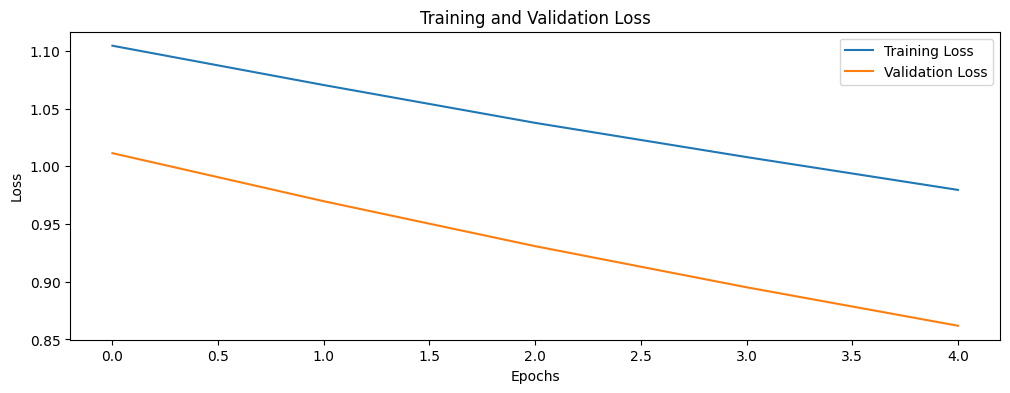

In [14]:
import matplotlib.pyplot as plt
# train the model and store the history
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

# plot the training and validation loss
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
